In [52]:
pip install pandas 


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [54]:
gasdata = pd.read_csv("C:/Users/abhik/OneDrive/Desktop/Coding stuff/Python/Forage - Quant Research/Nat_Gas.csv")


In [80]:
print(gasdata.shape)
gasdata.head()

(48, 5)


,Dates,Prices,Month,Year,days_from_start
0,2020-10-31,10.1,10,2020,0
1,2020-11-30,10.3,11,2020,30
2,2020-12-31,11.0,12,2020,61
3,2021-01-31,10.9,1,2021,92
4,2021-02-28,10.9,2,2021,120


In [56]:
# Cleaning the "Dates" variable so that it is in datetime format, allowing us to extract the month/year from the date and account for seasonal trends 
gasdata['Dates'] = pd.to_datetime(gasdata['Dates'])

C:\Users\abhik\AppData\Local\Temp\ipykernel_64368\1512687527.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gasdata['Dates'] = pd.to_datetime(gasdata['Dates'])


In [57]:
# Extracting the month and year from the date 
gasdata['Month'] = [i.month for i in gasdata['Dates']]
gasdata['Year'] = [i.year for i in gasdata['Dates']]

In [58]:
gasdata.head()

,Dates,Prices,Month,Year
0,2020-10-31,10.1,10,2020
1,2020-11-30,10.3,11,2020
2,2020-12-31,11.0,12,2020
3,2021-01-31,10.9,1,2021
4,2021-02-28,10.9,2,2021


<Axes: >

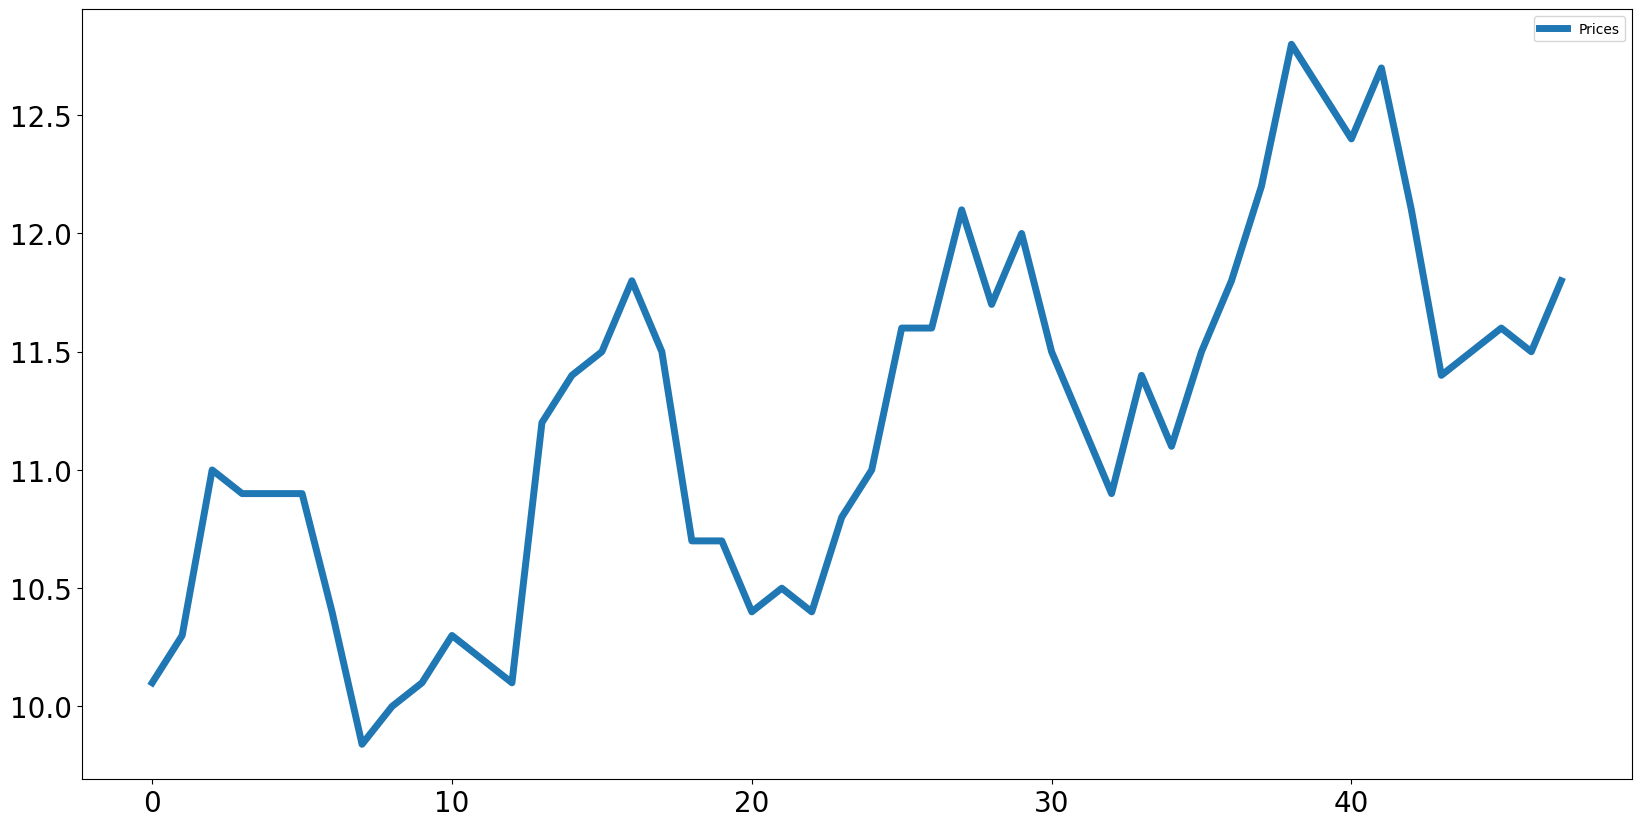

In [59]:
gasdata[['Prices']].plot(figsize = (20,10), linewidth = 5, fontsize = 20)


Text(0.5, 0, 'Year')

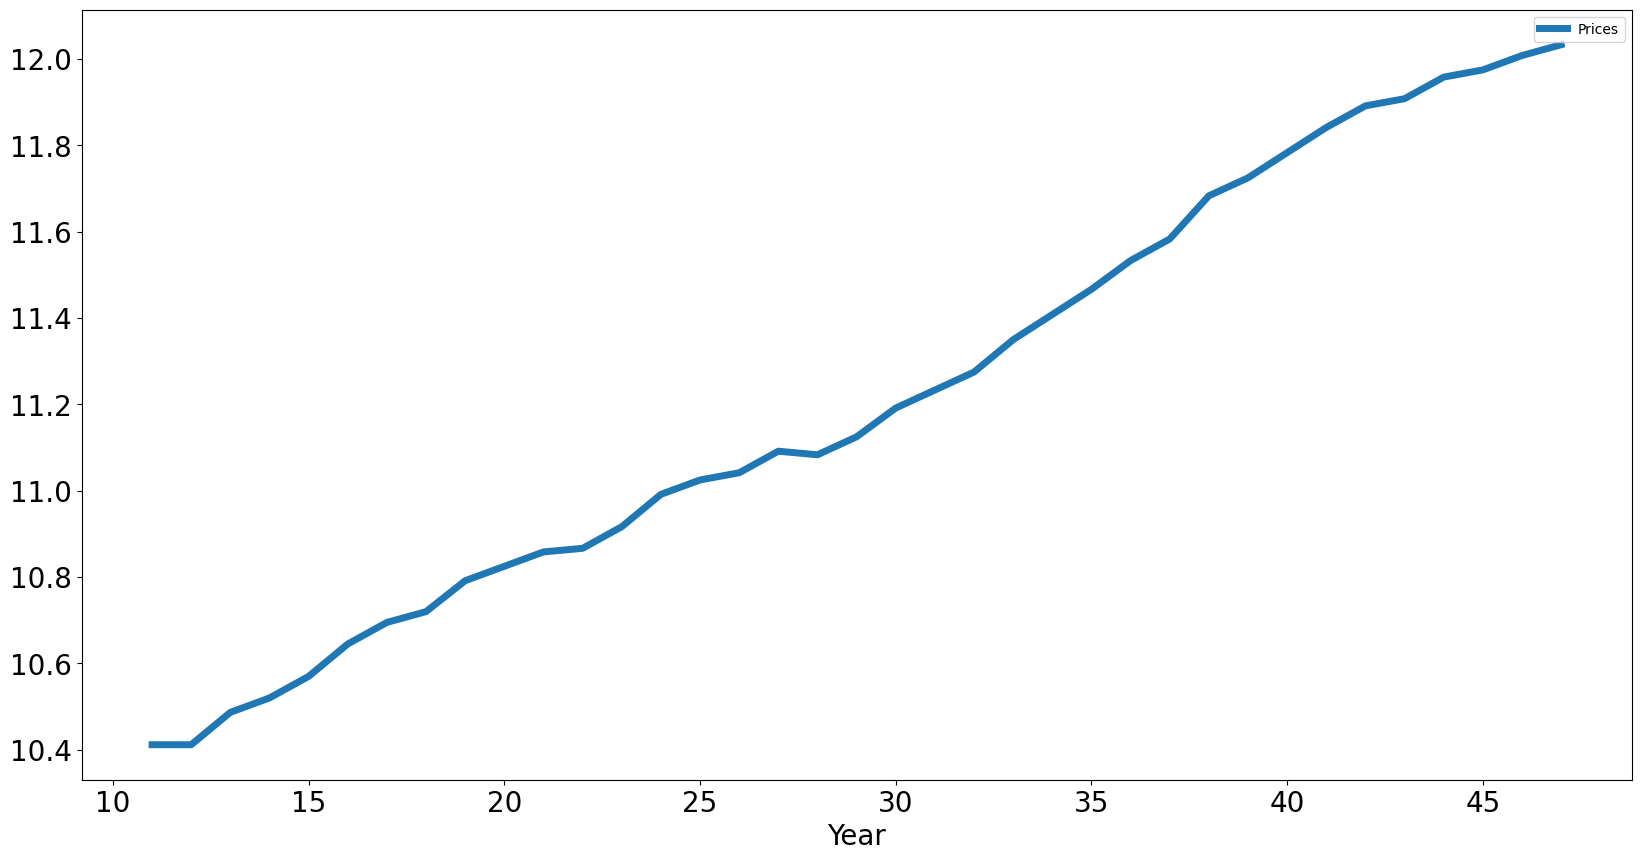

In [60]:
# Here, we take a rolling average of the series to smooth out noise and seasonality and get the core trend 
# I firstly set the window size to 12 to try out yearly seasonality 

prices = gasdata[['Prices']]
prices.rolling(12).mean().plot(figsize = (20,10), linewidth = 5, fontsize = 20)
plt.xlabel('Year', fontsize = 20)

In [61]:
# Getting dates in terms of days from the start to make it easier to interpolate later: 
from datetime import date, timedelta

start_date = date(2020, 10, 31)
end_date = date(2024, 9, 30)
months = []
year = start_date.year
month = start_date.month + 1 

while True: 
    current = date(year, month, 1) + timedelta(days= -1)
    months.append(current)
    if current.month == end_date.month and current.year == end_date.year: 
        break 
    else: 
        month = ((month + 1) % 12) or 12 
        if month == 1:
            year += 1
            
gasdata["days_from_start"] = [(day - start_date).days for day in months]



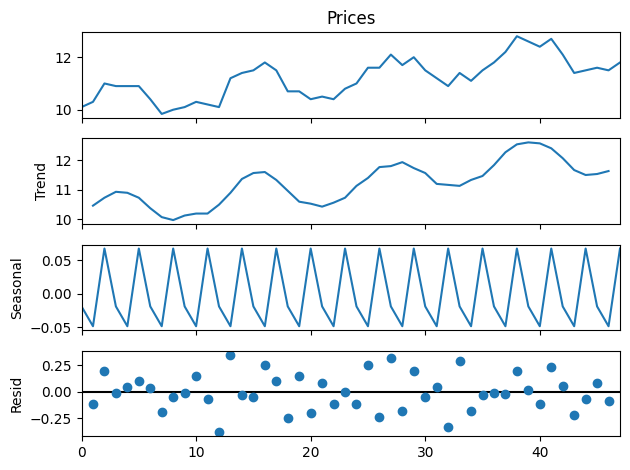

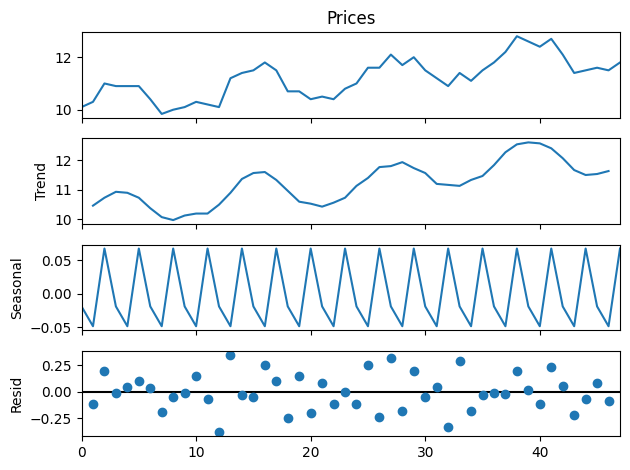

In [62]:
from statsmodels.tsa.seasonal import seasonal_decompose

y = gasdata["Prices"]
decomposition = seasonal_decompose(y, period = 3)

decomposition.plot()

Text(0.5, 0, '$k$')

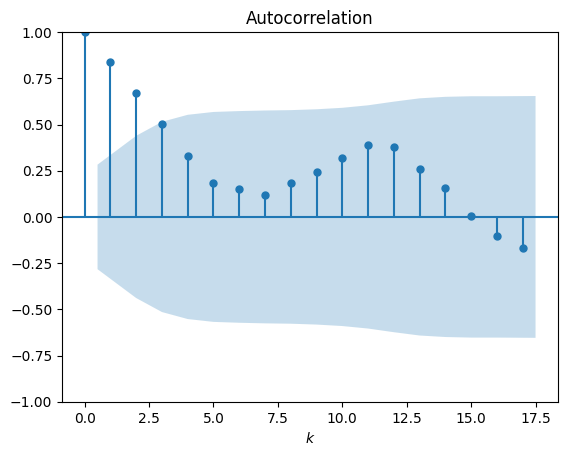

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(y)
plt.xlabel("$k$")

# We see from the ACF plot that the order of the MA is 3

Text(0.5, 0, '$k$')

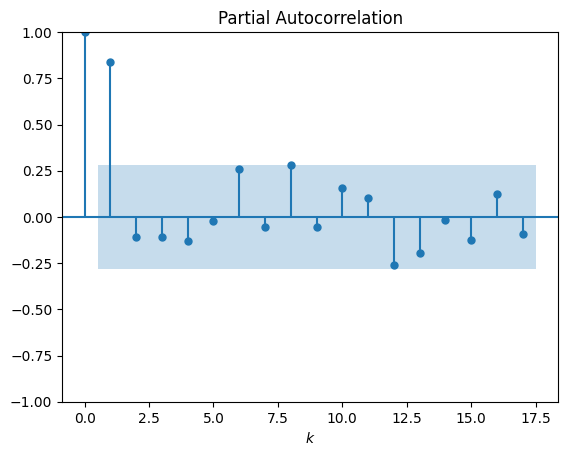

In [ ]:
plot_pacf(y)
plt.xlabel("$k$")

# We see from the plots of the PACF that the order of the AR is 4 as that is the first lag at which the autocorrelation between time t and lag k becomes insignificant 


In [ ]:
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.stattools import adfuller

print(adfuller(y))
print(adfuller(diff(y)))

# The results from the Augmented Dickey-Fuller test indicate that the "Prices" series, when first differenced, is still non-stationary
# The results from the Augmented Dickey-Fuller test indicate that the "Prices" series, when second differenced, is stationary 
# Therefore, the value for the difference (i.e. d) = 2


(0.21807686170000193, 0.9732574388448694, 10, 37, {'1%': -3.6209175221605827, '5%': -2.9435394610388332, '10%': -2.6104002410518627}, 10.198475035166425)
(-6.844773557477345, 1.754169685294091e-09, 9, 37, {'1%': -3.6209175221605827, '5%': -2.9435394610388332, '10%': -2.6104002410518627}, 8.91194325461305)


In [72]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y, order=(2, 2, 4))
model_fit = model.fit()
model_fit.summary()

c:\Users\abhik\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Prices   No. Observations:                   48
Model:                 ARIMA(2, 2, 4)   Log Likelihood                 -19.692
Date:                Mon, 16 Mar 2026   AIC                             53.384
Time:                        03:29:55   BIC                             66.185
Sample:                             0   HQIC                            58.180
                                 - 48                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3296      0.515     -2.580      0.010      -2.340      -0.320
ar.L2         -0.5044      0.464     -1.087      0.277      -1.414       0.405
ma.L1          0.6764   6693.930      0.000      1.000   -1.31e+04    1.31e+04
ma.L2         -0.8178   1.12e+04  -7.29e-05      1.000    -2.2e+04     2.2e+04
ma.L3         -0.9371   5748.883     -0.000      1.000   -1.13e+04    1.13e+04
ma.L4          0.0785    525.016      0.000      1.000   -1028.935    1029.092
sigma2         0.1169    782.930      0.000      1.000   -1534.398    1534.632
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 1.17
Prob(Q):                              0.82   Prob(JB):                         0.56
Heteroskedasticity (H):               0.78   Skew:                             0.26
Prob(H) (two-sided):                  0.63   Kurtosis:                         3.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [75]:
# Inspecting residuals: 

residuals = pd.DataFrame(model_fit.resid)
residuals.describe()


,0
count,48.000000
mean,0.082954
std,1.673896
min,-4.850000
25%,-0.259163
50%,-0.024728
75%,0.206268
max,10.100000


Text(0, 0.5, 'density')

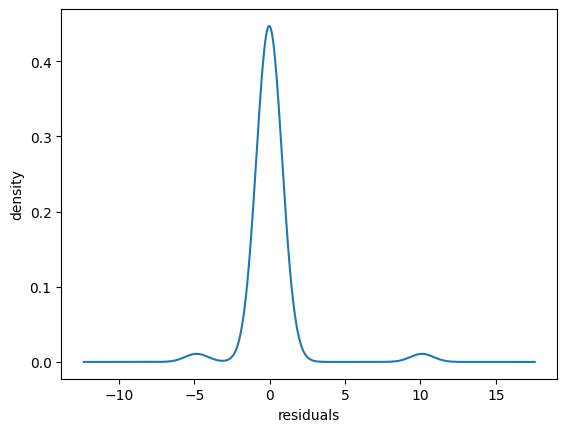

In [76]:
# Plotting residuals: 

residuals.plot(kind = "kde", legend = False)
plt.xlabel("residuals")
plt.ylabel("density")
    # The residuals appear to be distributed close to zero 

Text(0, 0.5, 'residuals')

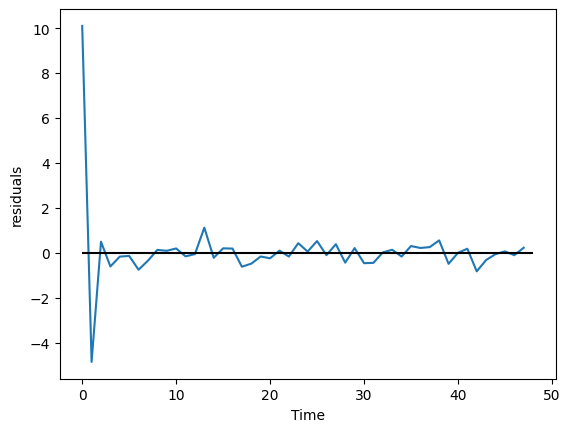

In [77]:
# Plotting residuals over time to inspect the outliers: 

residuals.plot(legend = False)
plt.hlines(0,0,48, color = "black")
plt.xlabel("Time")
plt.ylabel("residuals")

In [ ]:
# Forecasting: 

    # The task asks for a forecast for the next month
    # In lieu of this, a rolling monthly forecast may be appropriate


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import Ridge 
from sklearn.model_selection import cross_val_score 

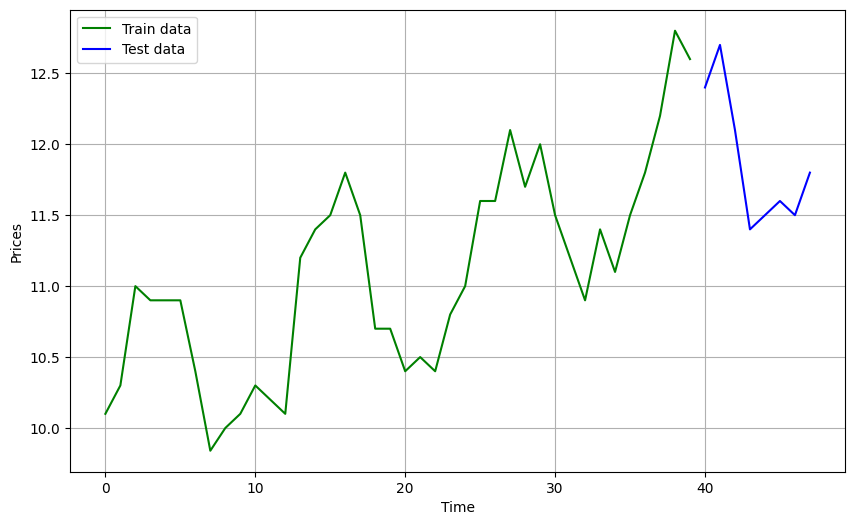

In [ ]:
# Splitting data into train and test sets: (?????)

train_data, test_data = gasdata[:int(len(gasdata)*0.85)], gasdata[int(len(gasdata)*0.85):]
# Plot train-test using matplotlib.pyplot
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Prices')
plt.plot(train_data[["Prices"]], 'green', label='Train data')
plt.plot(test_data[["Prices"]], 'blue', label='Test data')
plt.legend()


In [93]:
# Splitting data into test and train data: 

y_values = list(y.values)
train, test = y_values[0:30], y_values[30:40]

# Simulating monthly forecasting: 
predictions = []
current_params = None
for i in range(len(test)):
    model = ARIMA(train, order = (2,2,4))
    model_fit = model.fit(start_params = current_params)
    current_params = model_fit.params
    output = model_fit.forecast()
    predictions.append(output[0])
    train.append(test[i])

In [88]:
len(y_values)

48

In [94]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"RMSE: {rmse}")

RMSE: 0.38616646780048025


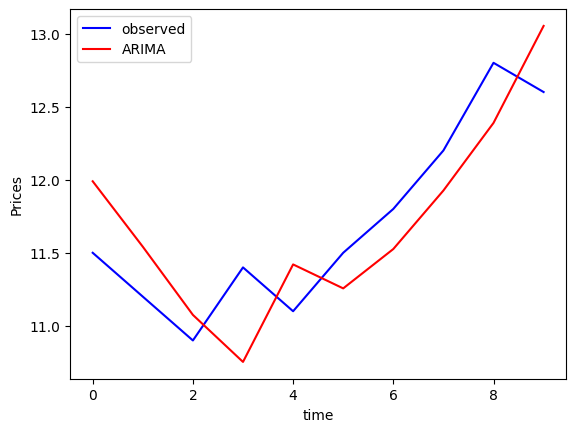

In [95]:
plt.plot(test, color="blue", label="observed")
plt.plot(predictions, color="red", label="ARIMA")
plt.xlabel("time")
plt.ylabel("Prices")
plt.legend()

We see that the ARIMA(2,2,4) model has a slight delay in predicting shocks/price movements. 